# REFMAP laboratory listening test 2 analysis: Exploratory data analysis — end response data

## Setup

In [269]:
# -*- coding: utf-8 -*-
import sys
import os
# Build a path from the notebook's parent directory to the python modules
module_path = os.path.abspath(os.path.join('..'))

# Add to sys.path if not already present
if module_path not in sys.path:
    sys.path.append(module_path)

# import statements
import numpy as np
import pandas as pd
from PyQt5.QtWidgets import QFileDialog, QApplication
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pingouin as pg
from numpy.random import Generator, PCG64
import soundscapy as sspy

In [38]:
# set plot parameters
sns.set_style('white')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams.update({'font.size': 16})
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['mathtext.fontset'] = 'stix'

SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE,
       labelsize=MEDIUM_SIZE)    # fontsize of the axes title and x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

mycolours = [(0, 102, 255), (0, 204, 153), (255, 0, 102), (74, 111, 152),
             (251, 164, 49), (204, 153, 255), (90, 192, 255), (80, 245, 233),
             (255, 90, 192), (164, 201, 242), (255, 254, 139), (255, 243, 255)]
mycolours = [tuple(shade/255 for shade in colour) for colour in mycolours]

numpy_randomGen = Generator(PCG64(303))

# enable copy-on-write mode for Pandas (will be default from Pandas 3.0)
pd.options.mode.copy_on_write = True

# check/open QApplication instance
if not QApplication.instance():
    app = QApplication(sys.argv)
else:
    app = QApplication.instance() 


Set the saveplots toggle to True if plot saving is desired:

In [3]:
saveplots=True

if saveplots:
    # select figure output save path
    outFigPath = QFileDialog.getExistingDirectory(caption=r"Select output folder to save plots '03 Experiment\Experiment 2\Analysis\Plots'")

    # create subfolders if not already existing
    try:
        os.mkdir(os.path.join(outFigPath, "svg"))
    except FileExistsError:
        pass

    try:
        os.mkdir(os.path.join(outFigPath, "pdf"))
    except FileExistsError:
        pass


## Functions

### Traditional rounding (for display)

In [4]:
def roundTrad(val, digits=3):
   return np.round(val+10**(-len(str(val))-1), digits)

In [5]:
def displayRndVal(val, digits=3, lessThanCrit=True):

    crit = 1/10**digits

    if val < crit and lessThanCrit:
        valString = "<" + str(crit)
    else:
        valRnd = roundTrad(val, digits)
        dec = str(valRnd).split('.')[-1]
        valString = str(valRnd)
        nzeros = digits - len(dec)
        if nzeros > 0:
            valString = valString + nzeros*"0"

    return(valString)

### General sigmoidal function for curve fitting

In [6]:
def sigmoid(x, q, k, v):
    y = 1 / (1 + q*np.exp(-k*x))**(1/v)
    return y

### General goodness-of-fit metrics for prediction models

In [7]:
def gof(data, predict, dof):
    residuals = data - predict  # residuals
    ss_res = np.sum(residuals**2)  # residual sum of squares
    ss_tot = np.sum((data - np.mean(data))**2)  # total sum of squares
    r_squared = 1 - (ss_res / ss_tot)  # coefficient of determination
    rse = np.sqrt(ss_res / dof)  # residual standard error
    return r_squared, rse

## Import data and organise

In [59]:
# import data
fileExts = "*.csv"

dataByStimFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest2_testdata_ByStim.csv",
                                                       caption=r"Open refmap_listest2_testdata_ByStim.csv in: \03 Experiment\Experiment 2\Analysis\PostProcess"))[0]
dataByStimTest = pd.read_csv(dataByStimFilePath, index_col=0)

subjDataFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest2_testdata_BySubj.csv",
                                                     caption=r"Open refmap_listest2_testdata_BySubj.csv in: \03 Experiment\Experiment 2\Analysis\PostProcess"))[0]
subjData = pd.read_csv(subjDataFilePath, index_col=False)


In [231]:
# categorise columns

for dataset in [dataByStimTest, subjData]:
    dataset['UASProximity'] = pd.Categorical(dataset['UASProximity'], ["Baseline", "Far", "Near"])
    dataset['AmbientEnv'] = pd.Categorical(dataset['AmbientEnv'], ["Park", "Residential", "Park (high)",
                                                                   "Highway (low)", "Streetside square",
                                                                   "Highway"])
    dataset['UASOperation'] = pd.Categorical(dataset['UASOperation'], ["Baseline", "Overflight", "Delivery"])
    dataset['UASType'] = pd.Categorical(dataset['UASType'], ["Baseline", "H520", "T150"])
    dataset['UASStart'] = pd.Categorical(dataset['UASStart'], ["Baseline", "Left", "Right"])


## Exploratory data analysis

In this section, exploratory plots are used to examine the Part A data for information and possible trends.

Responses are analysed using violin and scatter plots, segregating the data by the categorical variables UAS LAeq, Ambient environment type, UAS/Ambient signal-noise-ratio, UAS type, and flight operation type.

Noticeability of UAS is investigated using violin and scatter plots.

### Plotting detailed violin plots

In [219]:
def violin(data, x, y,
           xCats=None,
           xjitter=0.05,
           yjitter=0,
           yjitter_type="auto",
           palette=None,
           figsize=(7, 4),
           alpha_pt=0.2,
           size_pt=10,
           seed=123,
           ax=None):
    
    # remove any rows with missing data in the relevant columns
    data = data.dropna(subset=[x, y])

    rng = np.random.default_rng(seed)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    if palette is None:
        palette = list(mpl.colors.TABLEAU_COLORS.values())

    # ordered categories
    if xCats is None:
        xCats = list(data[x].sort_values().unique())


    y_data = []
    x_positions = []

    for ii, xcat in enumerate(xCats):

        sub = data[data[x] == xcat][y]

        if sub.empty:
            y_data.append([])
            x_positions.append(ii)
            continue

        yvals = sub.to_numpy().astype(float)

        # optional y jitter
        if yjitter:
            yvals = yvals + rng.normal(0, yjitter, len(yvals))

        xvals = np.full(len(yvals), ii, dtype=float)

        # ----------------------
        # density-aware x jitter
        # ----------------------
        if xjitter:

            if yjitter_type == "discrete" or (
                yjitter_type=="auto" and len(np.unique(yvals)) < len(yvals)*0.5
            ):

                # discrete counts
                unique_vals, counts = np.unique(yvals, return_counts=True)
                max_count = counts.max()

                for val, count in zip(unique_vals, counts):

                    idx = yvals == val
                    scale = xjitter * (count / max_count)

                    jitter = stats.t(loc=0,
                                     df=30,
                                     scale=scale).rvs(len(xvals[idx]),
                                                      random_state=Generator(PCG64(seed)))

                    xvals[idx] += jitter

            else:

                # continuous KDE scaling
                kde = gaussian_kde(yvals)
                dens = kde(yvals)
                dens_scaled = dens / dens.max()

                jitter = stats.t(loc=0,
                                     df=30,
                                     scale=xjitter*dens_scaled).rvs(len(xvals),
                                                                    random_state=Generator(PCG64(seed)))

                xvals += jitter

        ax.scatter(
            xvals,
            yvals,
            s=size_pt,
            facecolors="none",
            edgecolors=palette[ii],
            alpha=alpha_pt,
            linewidths=0.25
        )

        y_data.append(yvals)
        x_positions.append(ii)

    # ------------
    # violin layer
    # ------------

    violins = ax.violinplot(
        y_data,
        positions=x_positions,
        widths=0.45,
        bw_method="scott",
        showmeans=False,
        showmedians=False,
        showextrema=False
    )

    for ii, pc in enumerate(violins["bodies"]):

        pc.set_facecolor(palette[ii])
        pc.set_edgecolor([0.25, 0.25, 0.25])
        pc.set_linewidth(1)
        pc.set_alpha(0.2)

    # ---------------
    # boxplot overlay
    # ---------------

    medianprops = dict(
        linewidth=2,
        color=[0.2, 0.2, 0.2],
        solid_capstyle="butt"
    )

    boxprops = dict(
        linewidth=0.75,
        color=[0.2, 0.2, 0.2]
    )

    ax.boxplot(
        y_data,
        positions=x_positions,
        showfliers=False,
        showcaps=False,
        medianprops=medianprops,
        whiskerprops=boxprops,
        boxprops=boxprops,
        widths=0.25
    )

    ax.set(xticks=x_positions, xticklabels=xCats)

    return fig, ax

### Plotting split violin plots

In [218]:
def violinsplit(data, x, y, hue,
                xCats=None,
                xjitter=0.05,
                yjitter=0,
                yjitter_type="auto",
                med_trace=False,
                palette=None,
                alpha_pt=0.25,
                violin_width=0.5,
                figsize=(7, 4.65),
                size_pt=10,
                seed=123,
                ax=None):

    # remove any rows with missing data in the relevant columns
    data = data.dropna(subset=[x, y, hue])
    
    rng = np.random.default_rng(seed)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    if palette is None:
        # assign default palette
        palette = list(mpl.colors.TABLEAU_COLORS.values())

    if len(palette) > 2:
        palette = palette[0:2]

    # violin layer
    sns.violinplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        split=True,
        inner="quart",
        cut=0,
        width=violin_width,
        palette=palette,
        ax=ax
    )

    plt.setp(ax.collections, alpha=0.2)

    if xCats is None:
        xCats = list(data[x].sort_values().unique())

    hueCats = list(data[hue].sort_values().unique())

    shift = 0.055

    medians_A = []
    medians_B = []
    x_positions = []

    for ii, xcat in enumerate(xCats):

        for jj, hcat in enumerate(hueCats):

            sub = data[(data[x]==xcat) & (data[hue]==hcat)][y]

            if sub.empty:
                continue

            yvals = sub.to_numpy().astype(float)

            # optional y jitter
            if yjitter:
                yvals = yvals + rng.normal(0, yjitter, len(yvals))

            # base x location at split line
            xvals = np.full(len(yvals), ii, dtype=float)

            # determine side
            side_sign = -1 if jj == 0 else 1
            color = palette[jj]

            # ----------------------
            # density-aware x jitter
            # ----------------------

            if xjitter:

                if yjitter_type == "discrete" or (
                    yjitter_type=="auto" and len(np.unique(yvals)) < len(yvals)*0.5
                ):

                    # discrete counts
                    unique_vals, counts = np.unique(yvals, return_counts=True)
                    max_count = counts.max()

                    for val, count in zip(unique_vals, counts):

                        idx = yvals == val
                        scale = xjitter * (count / max_count)

                        jitter = np.abs(stats.t(loc=0,
                                                df=30,
                                                scale=scale).rvs(len(xvals[idx]),
                                                                 random_state=Generator(PCG64(seed))))
                        xvals[idx] += side_sign * jitter

                else:

                    # continuous: jitter proportional to KDE density
                    kde = gaussian_kde(yvals)
                    dens = kde(yvals)
                    dens_scaled = dens / dens.max()

                    jitter = np.abs(stats.t(loc=0,
                                            df=30,
                                            scale=xjitter*dens_scaled).rvs(len(xvals),
                                                                           random_state=Generator(PCG64(seed))))

                    xvals += side_sign * jitter
            
            else:
                xvals += side_sign * 0.02

            # prevent crossing split
            if jj == 0:
                xvals = np.minimum(xvals, ii)
                color = palette[0]
            else:
                xvals = np.maximum(xvals, ii)
                color = palette[1]

            ax.scatter(
                xvals,
                yvals,
                s=size_pt,
                facecolors="none",
                edgecolors=color,
                alpha=alpha_pt,
                linewidths=0.25
            )

            # store medians
            if jj == 0:
                medians_A.append(np.median(yvals))
            else:
                medians_B.append(np.median(yvals))

        x_positions.append(ii)

    # ------------
    # median trace
    # ------------

    if med_trace:

        if len(medians_A) == len(x_positions):
            ax.plot(
                np.array(x_positions) - 1.1*shift,
                medians_A,
                ":",
                color=palette[0],
                linewidth=2,
                alpha=0.4
            )

        if len(medians_B) == len(x_positions):
            ax.plot(
                np.array(x_positions) + 1.1*shift,
                medians_B,
                ":",
                color=palette[1],
                linewidth=2,
                alpha=0.4
            )

    ax.legend(bbox_to_anchor=(0.5, 1.2), loc="upper center", ncol=2)

    return fig, ax

### Facet plotting wrapper for violin plots

In [212]:
def violin_facet(data,
                 plot_func,
                 facet_col=None,
                 facet_row=None,
                 col_order=None,
                 row_order=None,
                 wrap_cols=None,
                 sharex=True,
                 sharey=True,
                 figsize=(10, 6),
                 panel_titles=True,
                 title_fmt="{row} | {col}",
                 legend=True,
                 legend_loc="upper center",
                 legend_ncol=None,
                 legend_bbox_to_anchor=None,
                 xlabel=None,
                 ylabel=None,
                 xticks=None,
                 yticks=None,
                 **plot_kwargs):

    import numpy as np
    import matplotlib.pyplot as plt

    if facet_col is None and facet_row is None:
        raise ValueError("At least one of facet_col or facet_row must be specified")

    # consistent x category ordering
    if "x" in plot_kwargs:
        xCats_global = list(data[plot_kwargs["x"]].sort_values().unique())
    else:
        xCats_global = None

    legend_handles = None
    legend_labels = None

    # =====================================================
    # WRAP MODE (single variable arranged into grid)
    # =====================================================

    if facet_row is None and wrap_cols is not None:

        facetCats = col_order if col_order else list(data[facet_col].sort_values().unique())

        ncols = wrap_cols
        nrows = int(np.ceil(len(facetCats) / wrap_cols))

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=figsize,
            sharex=sharex,
            sharey=sharey
        )

        axes = np.array(axes).reshape(-1)

        for ii, fcat in enumerate(facetCats):

            ax = axes[ii]

            sub = data[data[facet_col] == fcat]

            local_kwargs = plot_kwargs.copy()
            local_kwargs["ax"] = ax

            if xCats_global is not None:
                local_kwargs["xCats"] = xCats_global

            plot_func(sub, **local_kwargs)

            if legend and legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

            if ax.get_legend() is not None:
                ax.legend().remove()

            if panel_titles:
                ax.set_title(str(fcat))

            if xticks is not None:
                ax.set_xticks(xticks)

            if yticks is not None:
                ax.set_yticks(yticks)

            ax.set_xlabel("")
            ax.set_ylabel("")

        # hide unused axes
        for jj in range(ii + 1, len(axes)):
            axes[jj].set_visible(False)

    # =====================================================
    # GRID MODE (row × column facets)
    # =====================================================

    else:

        if facet_col:
            colCats = col_order if col_order else list(data[facet_col].sort_values().unique())
        else:
            colCats = [None]

        if facet_row:
            rowCats = row_order if row_order else list(data[facet_row].sort_values().unique())
        else:
            rowCats = [None]

        ncols = len(colCats)
        nrows = len(rowCats)

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=figsize,
            sharex=sharex,
            sharey=sharey
        )

        axes = np.array(axes).reshape(nrows, ncols)

        for ii, rcat in enumerate(rowCats):
            for jj, ccat in enumerate(colCats):

                ax = axes[ii, jj]

                sub = data.copy()

                if rcat is not None:
                    sub = sub[sub[facet_row] == rcat]

                if ccat is not None:
                    sub = sub[sub[facet_col] == ccat]

                local_kwargs = plot_kwargs.copy()
                local_kwargs["ax"] = ax

                if xCats_global is not None:
                    local_kwargs["xCats"] = xCats_global

                plot_func(sub, **local_kwargs)

                if legend and legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()

                if ax.get_legend() is not None:
                    ax.legend().remove()

                if panel_titles:

                    if facet_row and facet_col:
                        title = title_fmt.format(row=rcat, col=ccat)
                    elif facet_col:
                        title = str(ccat)
                    else:
                        title = str(rcat)

                    ax.set_title(title)

                if xticks is not None:
                    ax.set_xticks(xticks)

                if yticks is not None:
                    ax.set_yticks(yticks)

                ax.set_xlabel("")
                ax.set_ylabel("")

    # =====================================================
    # Shared legend
    # =====================================================

    if legend and legend_handles:

        if legend_ncol is None:
            legend_ncol = len(legend_labels)

        fig.legend(
            legend_handles,
            legend_labels,
            loc=legend_loc,
            ncol=legend_ncol,
            bbox_to_anchor=legend_bbox_to_anchor,
            frameon=False
        )

    # =====================================================
    # Global axis labels
    # =====================================================

    if xlabel:
        fig.supxlabel(xlabel)

    if ylabel:
        fig.supylabel(ylabel)

    fig.tight_layout()

    return fig, axes

### Ambient environment annoyance and soundscape distribution comparison

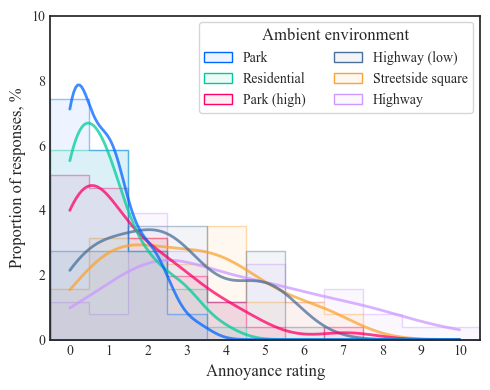

In [390]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.histplot(data=subjData[subjData['UASType'] == 'Baseline'],
             x='Annoyance', hue='AmbientEnv', stat='percent',
             discrete=True, palette=mycolours[0:6], kde=True,
             multiple='layer', element='step', ax=ax, alpha=0.07,
             legend=True, line_kws={'linewidth':2, 'alpha':0.75})

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.texts]
legend.remove()

ax.legend(handles, labels, ncol=2, title="Ambient environment")

ax.set(xticks=range(0, 11), yticks=range(0, 12, 2), xlim=[-0.5, 10.5],
       ylabel="Proportion of responses, %",
       xlabel="Annoyance rating")

# reduce the alpha of the histogram outlines to make them less visually dominant
# without affecting the alpha of the filled areas or of the KDE lines
edge_alpha = 0.4
mycolours_outline = [(*color, edge_alpha) for color in mycolours[0:6]]

ii = 5
for child in ax.get_children():
    if isinstance(child, mpl.collections.FillBetweenPolyCollection):
       # set the edge colour using the mycolours_outline list which has reduced alpha
       child.set_edgecolor(mycolours_outline[ii])
       ii -= 1

if saveplots:
    
    filename = "AmbAnnoyProp"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()

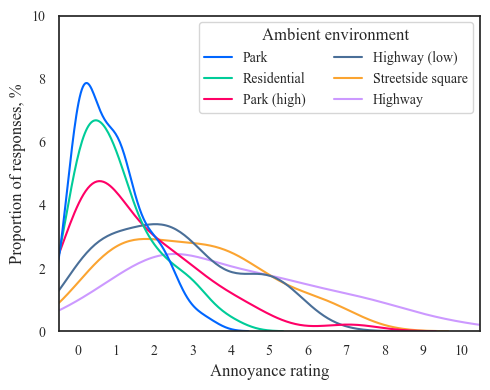

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.kdeplot(data=subjData[subjData['UASType'] == 'Baseline'],
             x='Annoyance', hue='AmbientEnv',
             palette=mycolours[0:6],
             multiple='layer', ax=ax,
             legend=True)

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.texts]
legend.remove()

ax.legend(handles, labels, ncol=2, title="Ambient environment")

ax.set(xticks=range(0, 11), xlim=[-0.5, 10.5], yticks=np.arange(0, 0.12, 0.02),
       yticklabels=np.arange(0, 12, 2),
       ylabel="Proportion of responses, %",
       xlabel="Annoyance rating")

if saveplots:

    filename = "AmbAnnoyPropKDE"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()

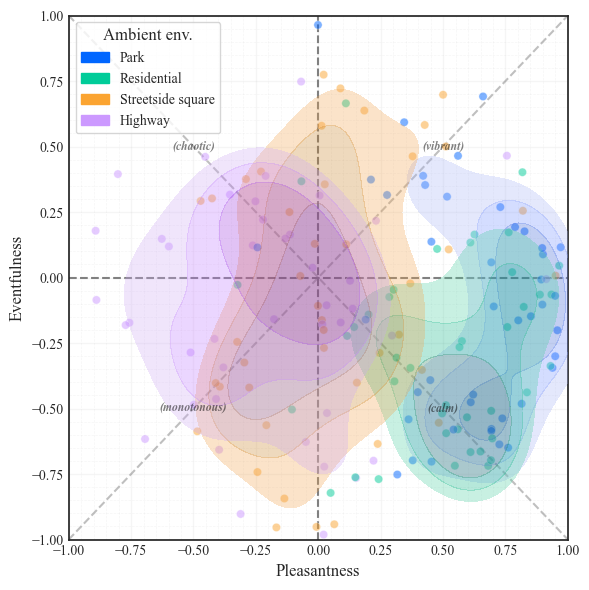

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

data = subjData.loc[(subjData['UASType'] == 'Baseline') &
                    (subjData['AmbientRef'] != "Park3Loud") &
                    (subjData['AmbientRef'] != "BusyStreet6Quiet"), :]
# recategorise AmbientEnv to omit the two excluded references
data['AmbientEnv'] = pd.Categorical(data['AmbientEnv'], ["Park", "Residential",
                                                         "Streetside square", "Highway"])
isop = sspy.plotting.density_plot(data=data,
                                  x='Pleasantness', y='Eventfulness', hue='AmbientEnv',
                                  palette=mycolours[0:2] + mycolours[4:6], legend=True,
                                  simple_density=True, simple_density_alpha=0.3,
                                  fill=True, simple_density_levels=4,
                                  ax=ax, apply_styling=False, title=None,
                                  diagonal_lines=True)

# reduce the alpha on all grid lines
isop.grid(alpha=0.075, which='both')

# reduce the alpha on all plotted points but not the density contours
for child in ax.get_children():
    if isinstance(child, mpl.collections.PathCollection):
        child.set_alpha(0.5)

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.texts]
legend.remove()

ax.legend(handles, labels, ncol=1, title="Ambient env.")

if saveplots:

    filename = "AmbPleasEvent"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()


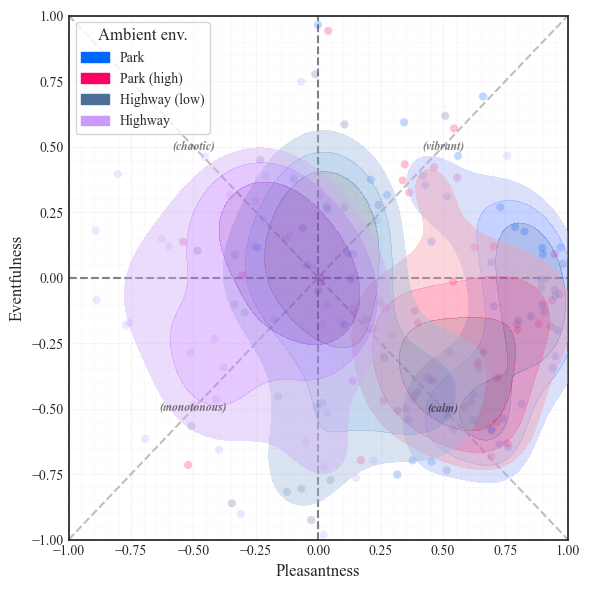

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

data = subjData.loc[(subjData['UASType'] == 'Baseline') &
                    (subjData['AmbientRef'] != "QuietStreet7") &
                    (subjData['AmbientRef'] != "BusyStreet8"), :]
# recategorise AmbientEnv to omit the two excluded reference`s
data['AmbientEnv'] = pd.Categorical(data['AmbientEnv'], ["Park", "Park (high)",
                                                         "Highway (low)", "Highway"])
isop = sspy.plotting.density_plot(data=data,
                                  x='Pleasantness', y='Eventfulness', hue='AmbientEnv',
                                  palette=[mycolours[0]] + mycolours[2:4] + [mycolours[5]],
                                  legend=True, simple_density=True, simple_density_alpha=0.4,
                                  fill=True, simple_density_levels=4,
                                  ax=ax, apply_styling=False, title=None,
                                  incl_scatter=True, diagonal_lines=True)

# reduce the alpha on all grid lines
isop.grid(alpha=0.075, which='both')


legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.texts]
legend.remove()

ax.legend(handles, labels, ncol=1, title="Ambient env.")
ax.set(xlim=[-1.0, 1.0], ylim=[-1.0, 1.0])

# reduce the alpha on all plotted points but not the density contours
for child in ax.get_children():
    if isinstance(child, mpl.collections.PathCollection):
        child.set_alpha(0.25)

if saveplots:

    filename = "AmbPleasEventParkHighway"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()


### Annoyance distribution relative to UAS proximity

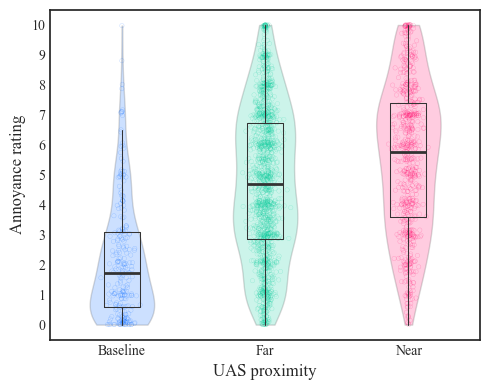

In [402]:
fig, ax = violin(subjData, x='UASProximity', y='Annoyance', palette=mycolours,
                 figsize=(5, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(0, 11), xlabel="UAS proximity",
       ylabel="Annoyance rating", ylim=[-0.5, 10.5])

if saveplots:

    filename = "AnnoyByProx"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

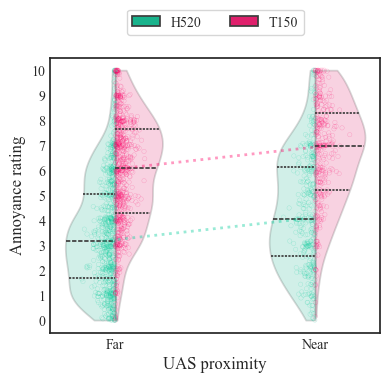

In [ ]:
data = subjData[subjData['UASType'] != 'Baseline']
# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])

fig, ax = violinsplit(data=data, x='UASProximity', y='Annoyance', hue='UASType',
                      palette=mycolours[1:], med_trace=True,
                      figsize=(4, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(0, 11), xlabel="UAS proximity",
       ylabel="Annoyance rating", ylim=[-0.5, 10.5])

if saveplots:

    filename = "AnnoyByProxByType"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

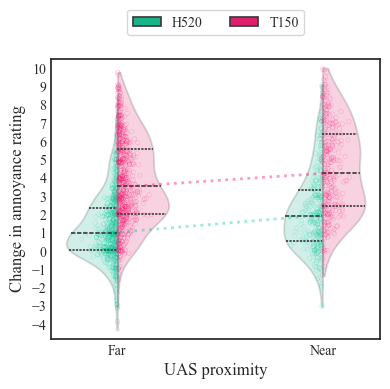

In [394]:
data = subjData[subjData['UASType'] != 'Baseline']
# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])

fig, ax = violinsplit(data=data, x='UASProximity', y='dAnnoyance', hue='UASType',
                      palette=mycolours[1:], med_trace=True,
                      figsize=(4, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(-4, 11), xlabel="UAS proximity",
       ylabel="Change in annoyance rating", ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByType"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

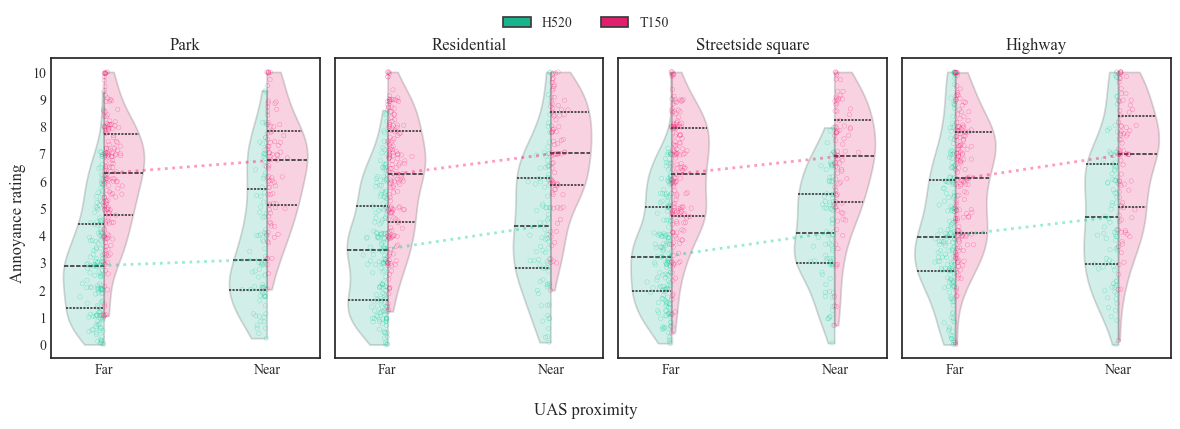

In [393]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv',
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {col}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='Annoyance', hue='UASType',
                        palette=mycolours[1:], med_trace=True,
                        figsize=(12, 4), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="Annoyance rating",
                        yticks=range(0, 11))

fig.tight_layout()

if saveplots:

    filename = "AnnoyByProxByTypeByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

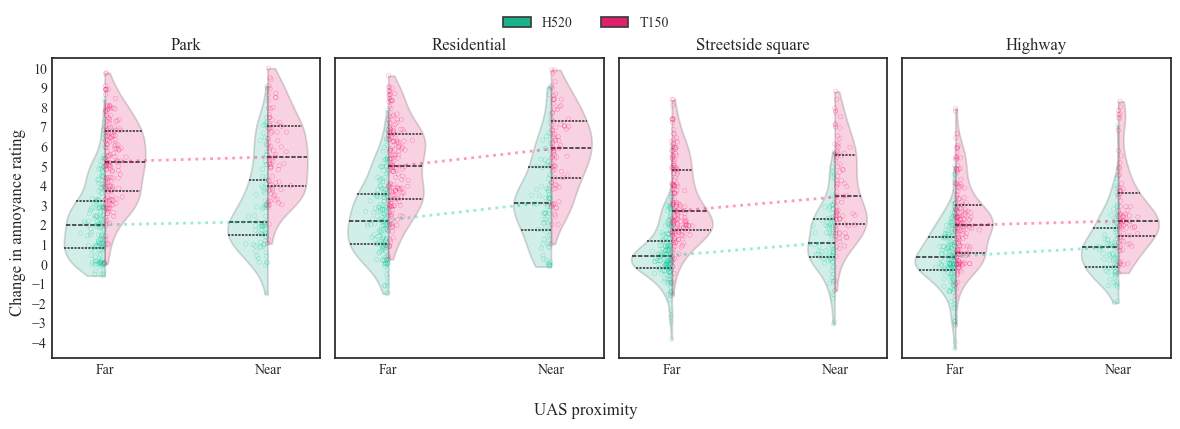

In [395]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', wrap_cols=None,
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {col}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='dAnnoyance', hue='UASType',
                        palette=mycolours[1:], med_trace=True,
                        figsize=(12, 4), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="Change in annoyance rating",
                        yticks=range(-4, 11))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByTypeByAmb"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

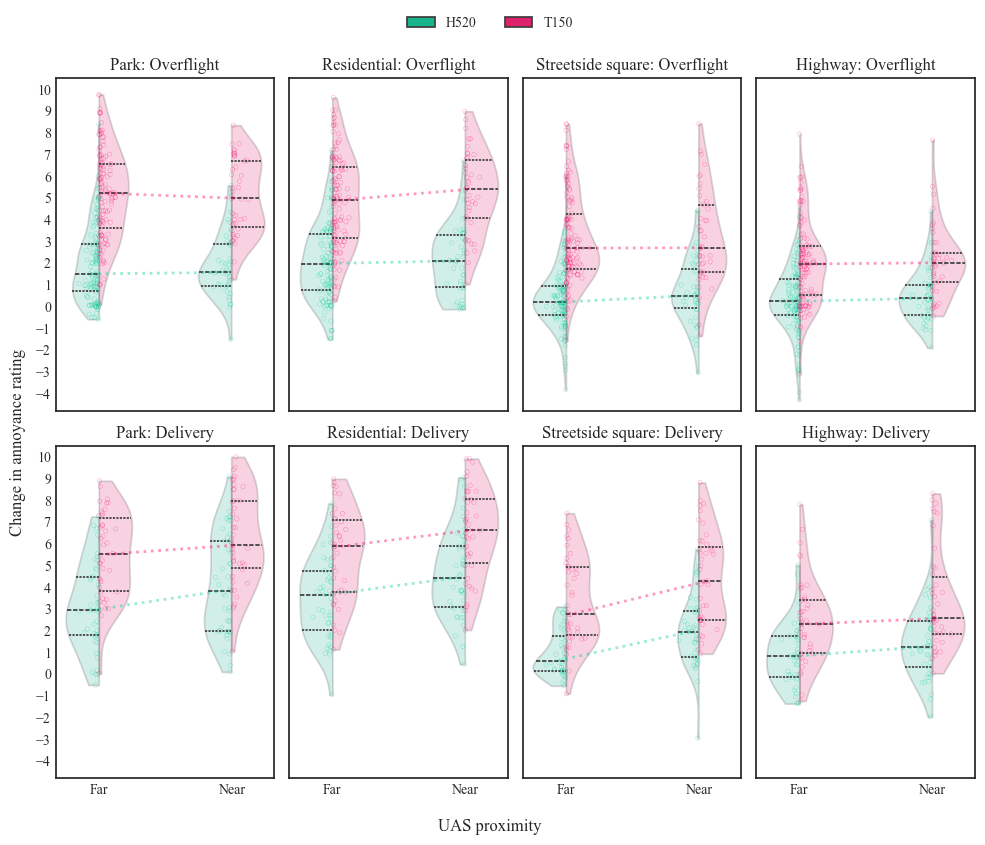

In [396]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', facet_row='UASOperation',
                        plot_func=violinsplit,
                        title_fmt="{col}: {row}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='dAnnoyance', hue='UASType',
                        palette=mycolours[1:], med_trace=True,
                        figsize=(10, 8), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="Change in annoyance rating",
                        yticks=range(-4, 11))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByTypeByOpByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

### Annoyance distribution relative to UAS operation

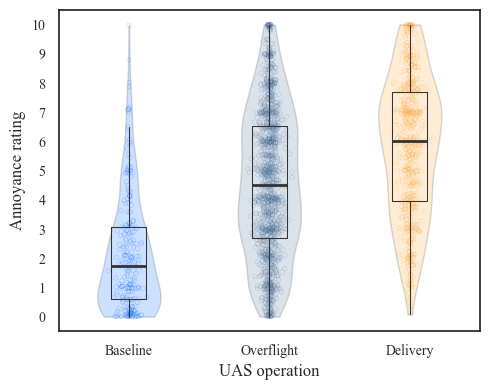

In [ ]:
fig, ax = violin(subjData, x='UASOperation', y='Annoyance', palette=[mycolours[0]] + mycolours[3:],
                 figsize=(5, 4), alpha_pt=0.4, size_pt=10)

ax.set(yticks=range(0, 11), xlabel="UAS operation",
       ylabel="Annoyance rating", ylim=[-0.5, 10.5])

if saveplots:
    
    filename = "AnnoyByOp"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

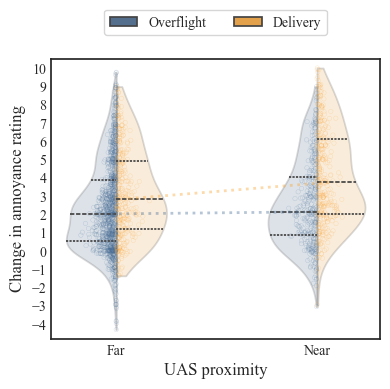

In [397]:
data = subjData[subjData['UASType'] != 'Baseline']
# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])

fig, ax = violinsplit(data=data, x='UASProximity', y='dAnnoyance', hue='UASOperation',
                      palette=mycolours[3:], med_trace=True,
                      figsize=(4, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(-4, 11), xlabel="UAS proximity",
       ylabel="Change in annoyance rating", ylim=[-4.8, 10.5])

if saveplots:
    
    filename = "dAnnoyByProxByOp"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

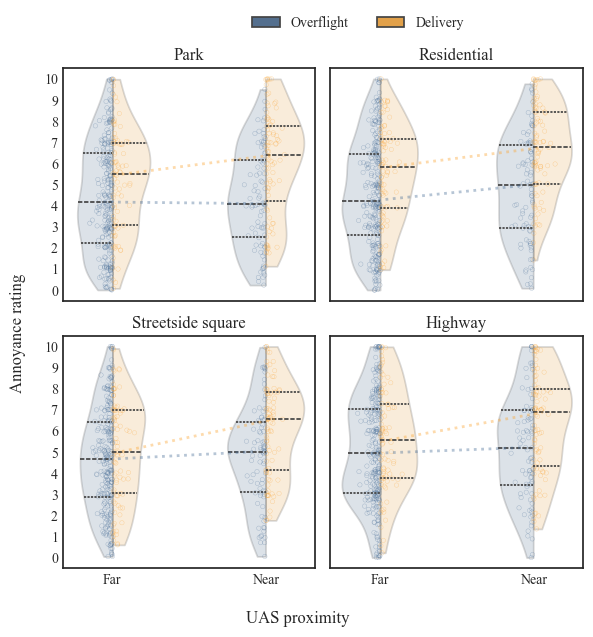

In [398]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', wrap_cols=2,
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {value}",
                        legend_bbox_to_anchor=(0.6, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='Annoyance', hue='UASOperation',
                        palette=mycolours[3:], med_trace=True,
                        figsize=(6, 6), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="Annoyance rating",
                        yticks=range(0, 11))

if saveplots:

    filename = "AnnoyByProxByOpByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

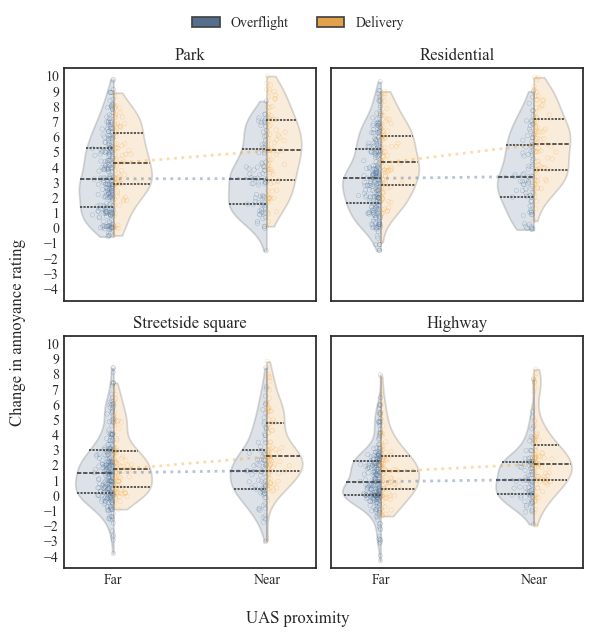

In [399]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', wrap_cols=2,
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {value}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='dAnnoyance', hue='UASOperation',
                        palette=mycolours[3:], med_trace=True,
                        figsize=(6, 6), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="Change in annoyance rating",
                        yticks=range(-4, 11))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByOpByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

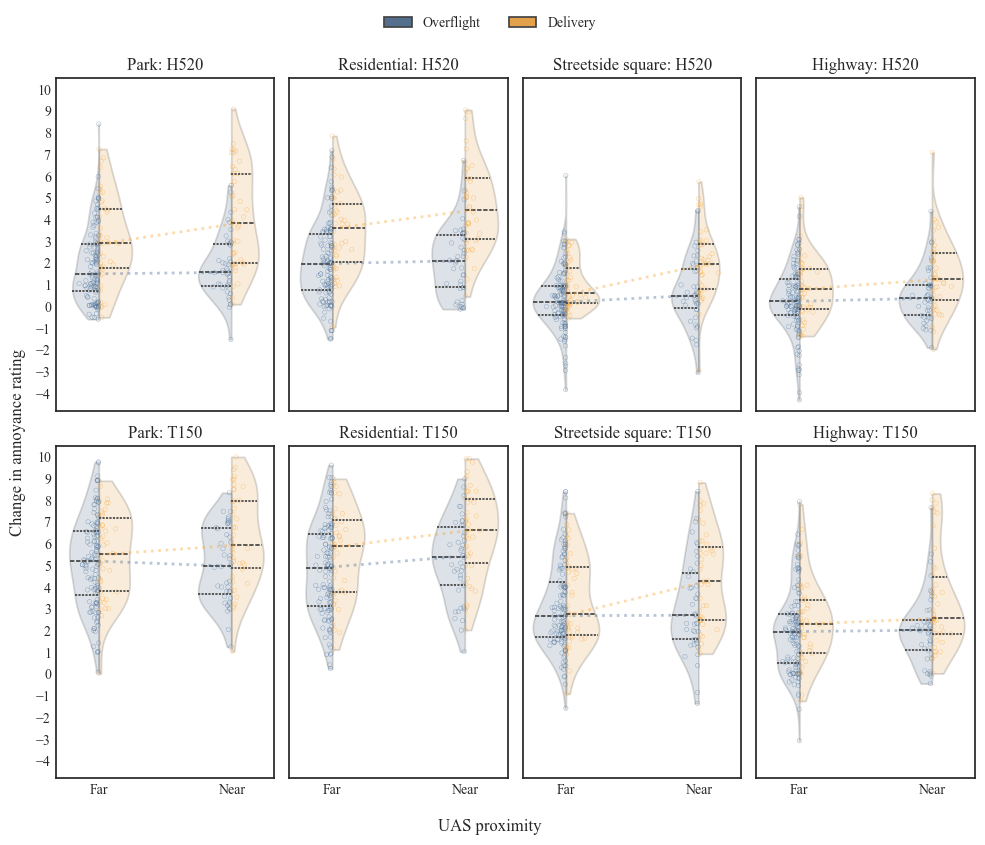

In [400]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', facet_row='UASType',
                        plot_func=violinsplit,
                        title_fmt="{col}: {row}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='dAnnoyance', hue='UASOperation',
                        palette=mycolours[3:], med_trace=True,
                        figsize=(10, 8), alpha_pt=0.7, size_pt=10,
                        xlabel="UAS proximity", ylabel="Change in annoyance rating",
                        yticks=range(-4, 11))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByOpByTypeByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

### Annoyance distribution relative to UAS events

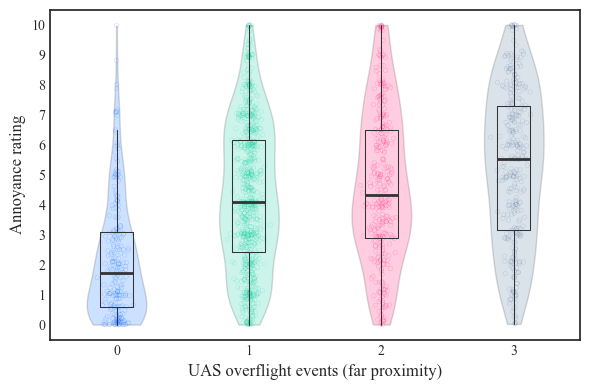

In [422]:
fig, ax = violin(subjData[subjData['UASOperation'] != 'Delivery'],
                 x='UASEvents', y='Annoyance', palette=mycolours,
                 figsize=(6, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(0, 11), xlabel="UAS overflight events (far proximity)", xticklabels=["0", "1", "2", "3"],
       ylabel="Annoyance rating", ylim=[-0.5, 10.5])

if saveplots:

    filename = "AnnoyByEvents"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

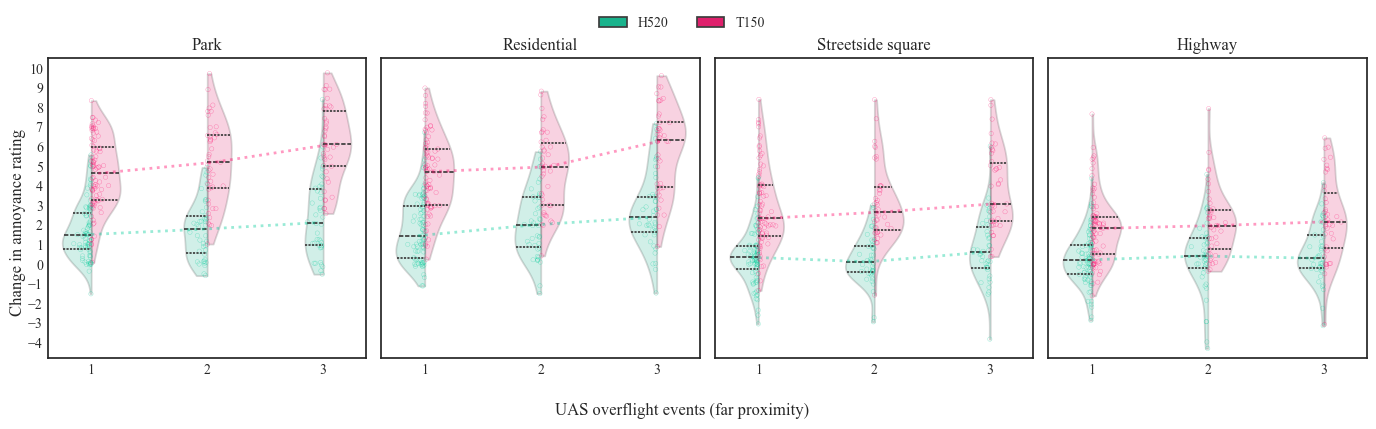

In [423]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet') &
                    (subjData['UASOperation'] != 'Delivery'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])

fig, axs = violin_facet(data=data, facet_col='AmbientEnv', wrap_cols=None,
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {col}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASEvents', y='dAnnoyance', hue='UASType',
                        palette=mycolours[1:], med_trace=True,
                        figsize=(14, 4), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS overflight events (far proximity)", ylabel="Change in annoyance rating",
                        yticks=range(-4, 11), xticks=range(0, 3))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5], xticklabels=["1", "2", "3"])

if saveplots:

    filename = "dAnnoyByEventsByTypeByAmb"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()